<a href="https://colab.research.google.com/github/Dokkae-bi/Intro-to-DL-Summer-26/blob/main/Homework1/Homework_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Homework 1: Problem 1 - Modified AlexNet on CIFAR-10

Importing the CIFAR-10 Dataset

In [1]:
import torchvision
from torchvision import transforms

# Where the data lives. Drive = downloads once and persists across sessions.
root = '/content/drive/MyDrive/cifar10-data'

# ToTensor() turns the PIL images into tensors in [0,1].
to_tensor = transforms.ToTensor()

train_set = torchvision.datasets.CIFAR10(root, train=True,  download=True, transform=to_tensor)
test_set  = torchvision.datasets.CIFAR10(root, train=False, download=True, transform=to_tensor)

print("train images:", len(train_set))   # 50000
print("test images: ", len(test_set))    # 10000
print("classes:", train_set.classes)
print("one image shape:", train_set[0][0].shape)  # torch.Size([3, 32, 32])

100%|██████████| 170M/170M [00:13<00:00, 12.7MB/s]


train images: 50000
test images:  10000
classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
one image shape: torch.Size([3, 32, 32])


Calculating the Mean and STD of the Dataset

In [2]:
import torch
from torchvision import transforms

stats_set = torchvision.datasets.CIFAR10(root, train=True, download=True,
                                         transform=transforms.ToTensor())

data = torch.stack([img for img, _ in stats_set])

mean = data.mean(dim=[0, 2, 3])
std  = data.std(dim=[0, 2, 3])

print("computed mean (R,G,B):", [round(v, 4) for v in mean.tolist()])
print("computed std  (R,G,B):", [round(v, 4) for v in std.tolist()])

computed mean (R,G,B): [0.4914, 0.4822, 0.4465]
computed std  (R,G,B): [0.247, 0.2435, 0.2616]


Normalizing the Dataset using the calculated values

In [3]:
# Normalize with the mean/std just measured
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist()),
])

# Reassign train_set/test_set to the normalized versions
train_set = torchvision.datasets.CIFAR10(root, train=True,  download=True, transform=transform)
test_set  = torchvision.datasets.CIFAR10(root, train=False, download=True, transform=transform)

# Sanity check
img, _ = train_set[0]
print("min / max:", round(img.min().item(), 3), "/", round(img.max().item(), 3))
print("this image's per-channel mean:", [round(v, 3) for v in img.mean(dim=[1, 2]).tolist()])

min / max: -1.989 / 2.095
this image's per-channel mean: [0.252, -0.288, -0.747]


Implimentation of AlexNet for 32x32 inputs

In [4]:
import torch.nn as nn

class ModifiedAlexNet(nn.Module):
    def __init__(self, num_classes=10, dropout_p=0.0):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1:  3x32x32 -> 64x16x16
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 2:  64x16x16 -> 128x8x8
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 3:  128x8x8 -> 256x4x4
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        # After features: 256 channels x 4 x 4 = 4096 values
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_p),
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

Sanity Check Running the Model and Parameter Count

In [5]:
import torch
from torchsummary import summary

model = ModifiedAlexNet(num_classes=10, dropout_p=0.0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

summary(model, (3, 32, 32))

total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total:,}")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
              ReLU-2           [-1, 64, 32, 32]               0
         MaxPool2d-3           [-1, 64, 16, 16]               0
            Conv2d-4          [-1, 128, 16, 16]          73,856
              ReLU-5          [-1, 128, 16, 16]               0
         MaxPool2d-6            [-1, 128, 8, 8]               0
            Conv2d-7            [-1, 256, 8, 8]         295,168
              ReLU-8            [-1, 256, 8, 8]               0
         MaxPool2d-9            [-1, 256, 4, 4]               0
          Flatten-10                 [-1, 4096]               0
          Dropout-11                 [-1, 4096]               0
           Linear-12                  [-1, 256]       1,048,832
             ReLU-13                  [-1, 256]               0
           Linear-14                   

Creating the Training/Validation/Test Split

In [6]:
import torch
from torch.utils.data import Subset

full_train = torchvision.datasets.CIFAR10(root, train=True, download=True, transform=transform)
test_set   = torchvision.datasets.CIFAR10(root, train=False, download=True, transform=transform)

# Deterministic 45k / 5k split, fixed seed
SEED = 42
n_val = 5000
g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(len(full_train), generator=g).tolist()   # shuffle 0..49999
val_idx, train_idx = perm[:n_val], perm[n_val:]

train_set = Subset(full_train, train_idx)   # 45,000
val_set   = Subset(full_train, val_idx)     # 5,000

print("train:", len(train_set), "| val:", len(val_set), "| test:", len(test_set))

train: 45000 | val: 5000 | test: 10000


Dataset Augmentation

In [7]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4, padding_mode='reflect'),  # shift by up to 4px
    transforms.RandomHorizontalFlip(),                             # mirror ~50% of the time
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist()),
])

train_full_aug = torchvision.datasets.CIFAR10(root, train=True, download=True,
                                              transform=train_transform)

train_set = Subset(train_full_aug, train_idx)

print("train (augmented):", len(train_set))
print("val   (clean):     ", len(val_set))
print("test  (clean):     ", len(test_set))

train (augmented): 45000
val   (clean):      5000
test  (clean):      10000


The DataLoader for the Dataset for the Model

In [8]:
from torch.utils.data import DataLoader

BATCH_SIZE = 256

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

x, y = next(iter(train_loader))
print("one batch of images:", x.shape)
print("one batch of labels:", y.shape)
print("number of training batches per epoch:", len(train_loader))

one batch of images: torch.Size([256, 3, 32, 32])
one batch of labels: torch.Size([256])
number of training batches per epoch: 176


Epoch Training

In [9]:
import copy
import time
import torch
import torch.nn as nn

# Hyperparameters
EPOCHS = 30
LR = 0.05
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Model from a fixed seed
torch.manual_seed(SEED)
model = ModifiedAlexNet(num_classes=10, dropout_p=0.0).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LR,
                            momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# Per-epoch metrics
history = {"train_loss": [], "val_loss": [], "val_acc": [], "epoch_time": []}
best_val_acc, best_state = 0.0, None


def train_one_epoch():
    model.train()
    running_loss, n = 0.0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        n += images.size(0)
    return running_loss / n


@torch.no_grad()
def evaluate(loader):
    model.eval()
    running_loss, correct, n = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        running_loss += criterion(outputs, labels).item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        n += images.size(0)
    return running_loss / n, 100.0 * correct / n


# --- main loop ---
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    train_loss = train_one_epoch()
    val_loss, val_acc = evaluate(val_loader)
    scheduler.step()
    epoch_time = time.time() - t0

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["epoch_time"].append(epoch_time)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = copy.deepcopy(model.state_dict())

    print(f"epoch {epoch:2d}/{EPOCHS} | train_loss {train_loss:.3f} | "
          f"val_loss {val_loss:.3f} | val_acc {val_acc:5.2f}% | {epoch_time:.1f}s")

avg_epoch = sum(history["epoch_time"]) / len(history["epoch_time"])
print(f"\nBest validation accuracy: {best_val_acc:.2f}%")
print(f"AlexNet avg epoch time: {avg_epoch:.1f}s")

epoch  1/30 | train_loss 1.714 | val_loss 1.285 | val_acc 54.04% | 14.5s
epoch  2/30 | train_loss 1.240 | val_loss 1.020 | val_acc 64.64% | 14.3s
epoch  3/30 | train_loss 1.022 | val_loss 0.916 | val_acc 67.52% | 14.3s
epoch  4/30 | train_loss 0.898 | val_loss 0.786 | val_acc 72.78% | 14.5s
epoch  5/30 | train_loss 0.798 | val_loss 0.701 | val_acc 75.84% | 14.3s
epoch  6/30 | train_loss 0.728 | val_loss 0.686 | val_acc 77.08% | 14.3s
epoch  7/30 | train_loss 0.683 | val_loss 0.595 | val_acc 79.26% | 14.5s
epoch  8/30 | train_loss 0.636 | val_loss 0.573 | val_acc 79.88% | 14.4s
epoch  9/30 | train_loss 0.589 | val_loss 0.564 | val_acc 80.70% | 14.4s
epoch 10/30 | train_loss 0.551 | val_loss 0.570 | val_acc 80.14% | 14.5s
epoch 11/30 | train_loss 0.527 | val_loss 0.536 | val_acc 81.92% | 14.2s
epoch 12/30 | train_loss 0.497 | val_loss 0.523 | val_acc 82.46% | 14.4s
epoch 13/30 | train_loss 0.463 | val_loss 0.471 | val_acc 83.56% | 14.3s
epoch 14/30 | train_loss 0.431 | val_loss 0.489 | v

Final test accuracy: 87.24%


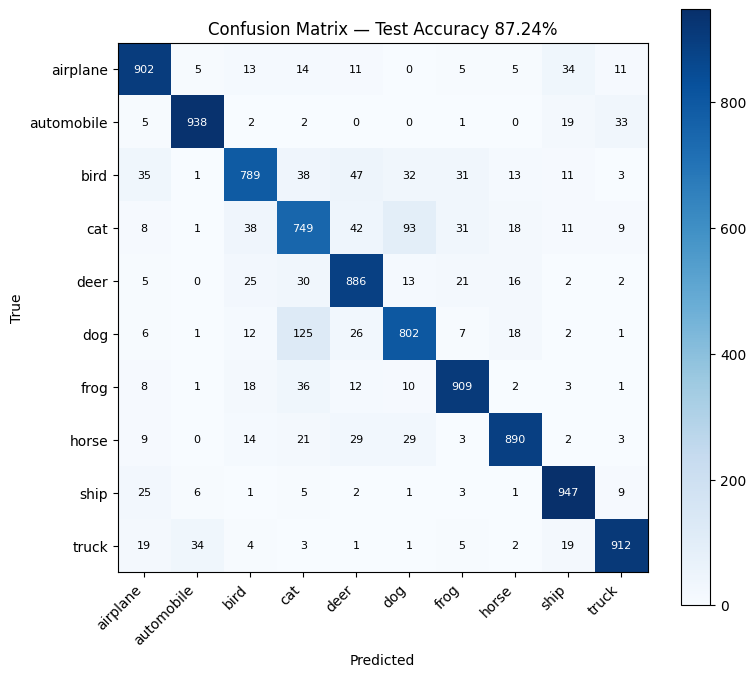

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Load the BEST weights
model.load_state_dict(best_state)
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        all_preds.append(outputs.argmax(1).cpu())
        all_labels.append(labels)

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

# --- Final test accuracy
test_acc = 100.0 * (all_preds == all_labels).mean()
print(f"Final test accuracy: {test_acc:.2f}%")

# --- Confusion matrix
classes = full_train.classes
n = len(classes)
cm = np.zeros((n, n), dtype=int)
np.add.at(cm, (all_labels, all_preds), 1)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Blues')
fig.colorbar(im)
ax.set(xticks=range(n), yticks=range(n),
       xticklabels=classes, yticklabels=classes,
       xlabel='Predicted', ylabel='True',
       title=f'Confusion Matrix — Test Accuracy {test_acc:.2f}%')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
for i in range(n):
    for j in range(n):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=8)
plt.tight_layout()
plt.show()

Filter Visualization

first conv filters shape: torch.Size([64, 3, 3, 3])


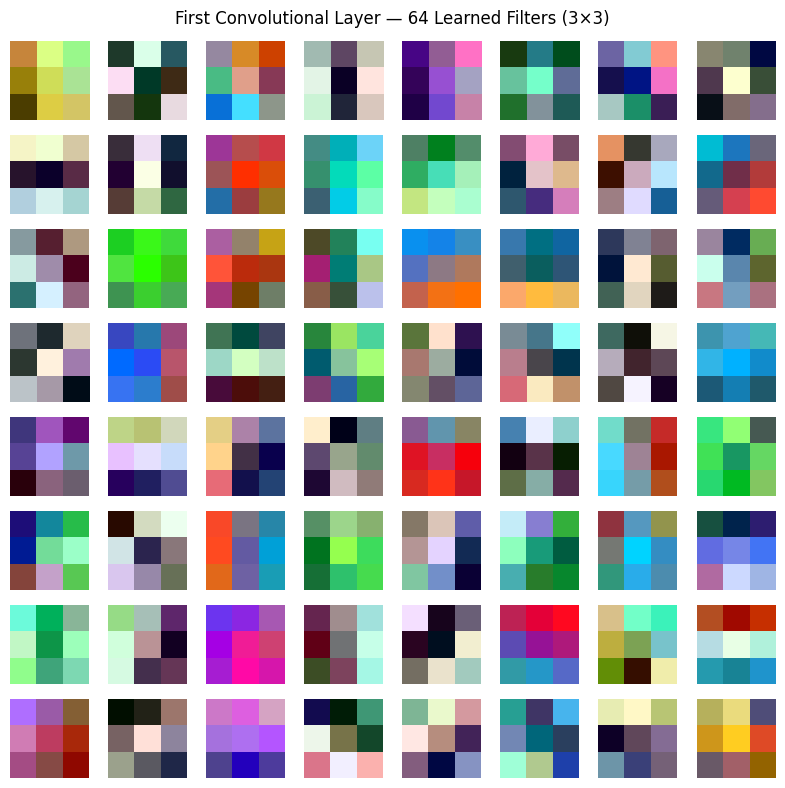

In [11]:
import matplotlib.pyplot as plt

model.load_state_dict(best_state)

first_conv = model.features[0]
weights = first_conv.weight.detach().cpu()
print("first conv filters shape:", weights.shape)

# Normalize each filter to [0,1] just for display
def norm(f):
    f = f - f.min()
    return f / f.max() if f.max() > 0 else f

cols = 8
rows = 8
fig, axes = plt.subplots(rows, cols, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.axis('off')
    if i < weights.shape[0]:
        f = norm(weights[i]).permute(1, 2, 0)
        ax.imshow(f.numpy())
fig.suptitle('First Convolutional Layer — 64 Learned Filters (3×3)')
plt.tight_layout()
plt.show()

Training Curves

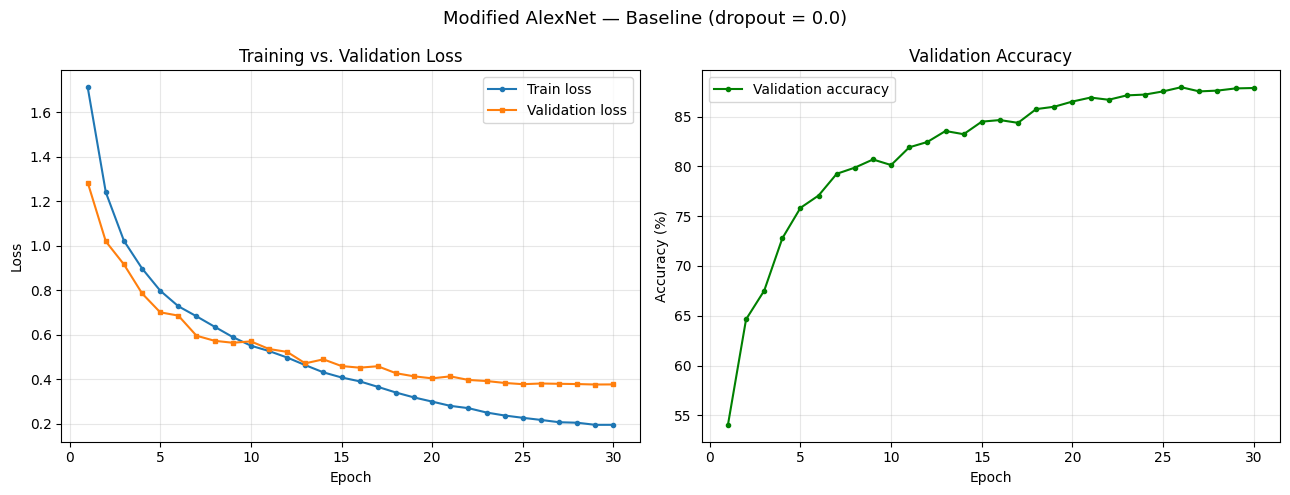

In [12]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(13, 5))

# loss curves (train vs val)
ax_loss.plot(epochs, history["train_loss"], label="Train loss", marker='o', markersize=3)
ax_loss.plot(epochs, history["val_loss"],   label="Validation loss", marker='s', markersize=3)
ax_loss.set_xlabel("Epoch")
ax_loss.set_ylabel("Loss")
ax_loss.set_title("Training vs. Validation Loss")
ax_loss.legend()
ax_loss.grid(True, alpha=0.3)

# validation accuracy
ax_acc.plot(epochs, history["val_acc"], label="Validation accuracy",
            color="green", marker='o', markersize=3)
ax_acc.set_xlabel("Epoch")
ax_acc.set_ylabel("Accuracy (%)")
ax_acc.set_title("Validation Accuracy")
ax_acc.legend()
ax_acc.grid(True, alpha=0.3)

fig.suptitle("Modified AlexNet — Baseline (dropout = 0.0)", fontsize=13)
plt.tight_layout()
plt.show()

Problem 1 Part B: Dropout

In [13]:
import copy
import torch
import torch.nn as nn

EPOCHS = 30
LR = 0.05
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.manual_seed(SEED)
model = ModifiedAlexNet(num_classes=10, dropout_p=0.0).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

baseline_history = {"train_loss": [], "val_loss": [], "val_acc": []}
baseline_best_acc, baseline_best_state = 0.0, None

for epoch in range(1, EPOCHS + 1):
    model.train()
    running, n = 0.0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        running += loss.item() * images.size(0); n += images.size(0)
    train_loss = running / n

    model.eval()
    vrunning, correct, vn = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            out = model(images)
            vrunning += criterion(out, labels).item() * images.size(0)
            correct += (out.argmax(1) == labels).sum().item(); vn += images.size(0)
    val_loss, val_acc = vrunning / vn, 100.0 * correct / vn
    scheduler.step()

    baseline_history["train_loss"].append(train_loss)
    baseline_history["val_loss"].append(val_loss)
    baseline_history["val_acc"].append(val_acc)
    if val_acc > baseline_best_acc:
        baseline_best_acc = val_acc
        baseline_best_state = copy.deepcopy(model.state_dict())

    print(f"epoch {epoch:2d}/{EPOCHS} | train {train_loss:.3f} | val {val_loss:.3f} | val_acc {val_acc:5.2f}%")

print(f"\nBaseline best val acc: {baseline_best_acc:.2f}%")

epoch  1/30 | train 1.716 | val 1.316 | val_acc 52.60%
epoch  2/30 | train 1.241 | val 1.029 | val_acc 64.12%
epoch  3/30 | train 1.019 | val 0.901 | val_acc 68.78%
epoch  4/30 | train 0.906 | val 0.791 | val_acc 72.62%
epoch  5/30 | train 0.803 | val 0.701 | val_acc 75.22%
epoch  6/30 | train 0.731 | val 0.671 | val_acc 77.04%
epoch  7/30 | train 0.678 | val 0.606 | val_acc 78.26%
epoch  8/30 | train 0.632 | val 0.553 | val_acc 80.52%
epoch  9/30 | train 0.587 | val 0.544 | val_acc 81.16%
epoch 10/30 | train 0.550 | val 0.550 | val_acc 80.48%
epoch 11/30 | train 0.526 | val 0.517 | val_acc 82.24%
epoch 12/30 | train 0.489 | val 0.531 | val_acc 81.42%
epoch 13/30 | train 0.467 | val 0.463 | val_acc 83.52%
epoch 14/30 | train 0.426 | val 0.458 | val_acc 83.80%
epoch 15/30 | train 0.406 | val 0.448 | val_acc 84.34%
epoch 16/30 | train 0.381 | val 0.443 | val_acc 85.18%
epoch 17/30 | train 0.362 | val 0.447 | val_acc 85.12%
epoch 18/30 | train 0.336 | val 0.419 | val_acc 86.26%
epoch 19/3

In [14]:
import copy

EPOCHS = 30
LR = 0.05
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4

results = {}

for p in [0.3, 0.5]:
    print(f"\n{'='*55}\nTraining with dropout_p = {p}\n{'='*55}")

    torch.manual_seed(SEED)
    model = ModifiedAlexNet(num_classes=10, dropout_p=p).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=LR,
                                momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_val_acc, best_state = 0.0, None

    for epoch in range(1, EPOCHS + 1):
        model.train()
        running, n = 0.0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            running += loss.item() * images.size(0); n += images.size(0)
        train_loss = running / n

        model.eval()
        vrunning, correct, vn = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                out = model(images)
                vrunning += criterion(out, labels).item() * images.size(0)
                correct += (out.argmax(1) == labels).sum().item(); vn += images.size(0)
        val_loss, val_acc = vrunning / vn, 100.0 * correct / vn
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        print(f"epoch {epoch:2d}/{EPOCHS} | train {train_loss:.3f} | "
              f"val {val_loss:.3f} | val_acc {val_acc:5.2f}%")

    results[p] = {"history": history, "best_val_acc": best_val_acc, "best_state": best_state}
    print(f"dropout {p}: best val acc {best_val_acc:.2f}%")

print("\nDone. Baseline was 87.58%. Dropout results:")
for p in results:
    print(f"  dropout {p}: {results[p]['best_val_acc']:.2f}%")


Training with dropout_p = 0.3
epoch  1/30 | train 1.730 | val 1.301 | val_acc 53.42%
epoch  2/30 | train 1.283 | val 1.172 | val_acc 59.36%
epoch  3/30 | train 1.063 | val 0.886 | val_acc 68.78%
epoch  4/30 | train 0.947 | val 0.815 | val_acc 71.84%
epoch  5/30 | train 0.851 | val 0.728 | val_acc 74.80%
epoch  6/30 | train 0.784 | val 0.664 | val_acc 77.08%
epoch  7/30 | train 0.742 | val 0.604 | val_acc 79.02%
epoch  8/30 | train 0.687 | val 0.581 | val_acc 79.64%
epoch  9/30 | train 0.658 | val 0.562 | val_acc 80.34%
epoch 10/30 | train 0.620 | val 0.551 | val_acc 80.62%
epoch 11/30 | train 0.585 | val 0.542 | val_acc 80.90%
epoch 12/30 | train 0.566 | val 0.586 | val_acc 79.66%
epoch 13/30 | train 0.537 | val 0.490 | val_acc 83.26%
epoch 14/30 | train 0.507 | val 0.473 | val_acc 83.36%
epoch 15/30 | train 0.488 | val 0.477 | val_acc 83.38%
epoch 16/30 | train 0.467 | val 0.442 | val_acc 85.04%
epoch 17/30 | train 0.444 | val 0.460 | val_acc 84.56%
epoch 18/30 | train 0.420 | val 0.

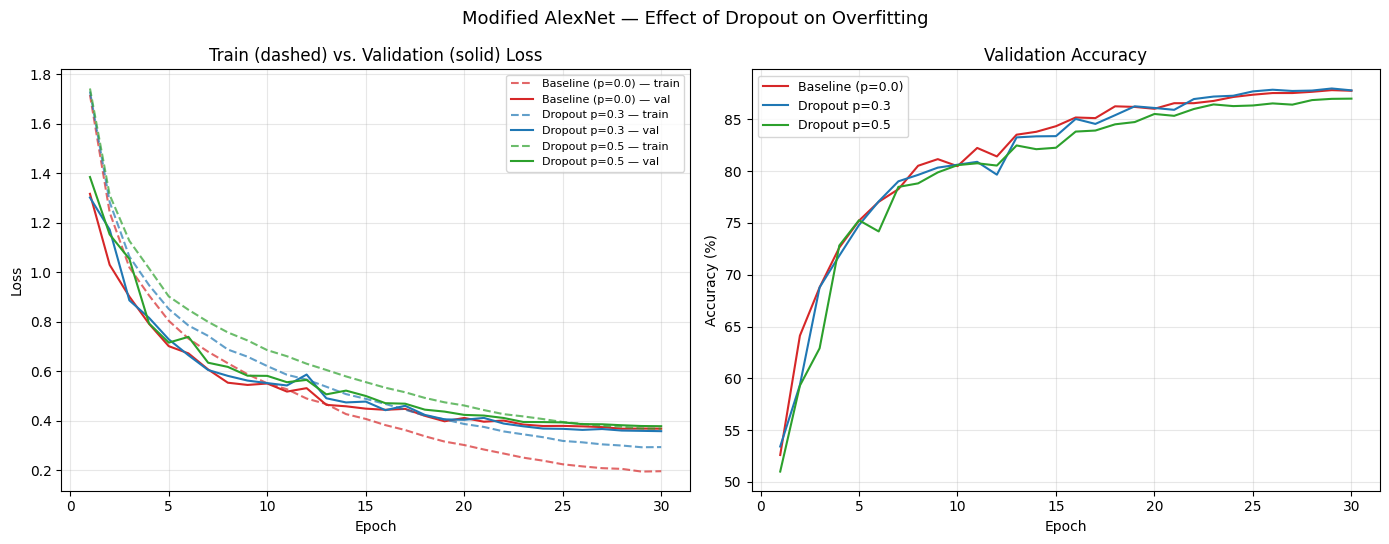

In [15]:
import matplotlib.pyplot as plt

epochs = range(1, EPOCHS + 1)

runs = {
    "Baseline (p=0.0)": baseline_history,
    "Dropout p=0.3":    results[0.3]["history"],
    "Dropout p=0.5":    results[0.5]["history"],
}
colors = {"Baseline (p=0.0)": "tab:red",
          "Dropout p=0.3": "tab:blue",
          "Dropout p=0.5": "tab:green"}

fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(14, 5.5))

for name, h in runs.items():
    c = colors[name]
    ax_loss.plot(epochs, h["train_loss"], color=c, linestyle="--", alpha=0.7, label=f"{name} — train")
    ax_loss.plot(epochs, h["val_loss"], color=c, linestyle="-", label=f"{name} — val")
ax_loss.set_xlabel("Epoch"); ax_loss.set_ylabel("Loss")
ax_loss.set_title("Train (dashed) vs. Validation (solid) Loss")
ax_loss.legend(fontsize=8); ax_loss.grid(True, alpha=0.3)

for name, h in runs.items():
    ax_acc.plot(epochs, h["val_acc"], color=colors[name], label=name)
ax_acc.set_xlabel("Epoch"); ax_acc.set_ylabel("Accuracy (%)")
ax_acc.set_title("Validation Accuracy")
ax_acc.legend(fontsize=9); ax_acc.grid(True, alpha=0.3)

fig.suptitle("Modified AlexNet — Effect of Dropout on Overfitting", fontsize=13)
plt.tight_layout()
plt.show()

Problem 2: Modified VGGNet on CIFAR-10

 Calculates all four variants' adapted parameter counts and how far each is from the 1.42M Parameter count

In [16]:
import torch
import torch.nn as nn

VGG_CONFIGS = {
    "VGG11": [64, "M", 128, "M", 256, 256, "M", 512, 512, "M", 512, 512, "M"],
    "VGG13": [64, 64, "M", 128, 128, "M", 256, 256, "M", 512, 512, "M", 512, 512, "M"],
    "VGG16": [64, 64, "M", 128, 128, "M", 256, 256, 256, "M", 512, 512, 512, "M", 512, 512, 512, "M"],
    "VGG19": [64, 64, "M", 128, 128, "M", 256, 256, 256, 256, "M", 512, 512, 512, 512, "M", 512, 512, 512, 512, "M"],
}

def make_features(cfg):
    layers, in_ch = [], 3
    for v in cfg:
        if v == "M":
            layers += [nn.MaxPool2d(2)]
        else:
            layers += [nn.Conv2d(in_ch, v, kernel_size=3, padding=1), nn.ReLU(inplace=True)]
            in_ch = v
    return nn.Sequential(*layers)

class AdaptedVGG(nn.Module):
    def __init__(self, cfg, num_classes=10, head_hidden=256, dropout_p=0.0):
        super().__init__()
        self.features = make_features(cfg)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_p),
            nn.LazyLinear(head_hidden),
            nn.ReLU(inplace=True),
            nn.Linear(head_hidden, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

def count(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

In [17]:
import torch


def scaled_vgg11_cfg(scale):
    base = [64, "M", 128, "M", 256, 256, "M", 512, 512, "M", 512, 512, "M"]
    return [max(8, round(v * scale / 8) * 8) if v != "M" else "M" for v in base]

SCALE = 0.4
vgg11_cfg = scaled_vgg11_cfg(SCALE)
vgg_model = AdaptedVGG(vgg11_cfg, num_classes=10, head_hidden=256)

_ = vgg_model(torch.zeros(1, 3, 32, 32))

widths = [v for v in vgg11_cfg if v != "M"]
n_params = count(vgg_model)
print(f"Narrowed VGG-11 channel widths: {widths}")
print(f"Trainable parameters: {n_params:,}")
print(f"Target (AlexNet): 1,422,218  |  Difference: {n_params - 1_422_218:+,}")

Narrowed VGG-11 channel widths: [24, 48, 104, 104, 208, 208, 208, 208]
Trainable parameters: 1,573,290
Target (AlexNet): 1,422,218  |  Difference: +151,072


Sanity Check

In [18]:
from torchsummary import summary
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
vgg_model = vgg_model.to(device)

summary(vgg_model, (3, 32, 32))

total = sum(p.numel() for p in vgg_model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total:,}")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 24, 32, 32]             672
              ReLU-2           [-1, 24, 32, 32]               0
         MaxPool2d-3           [-1, 24, 16, 16]               0
            Conv2d-4           [-1, 48, 16, 16]          10,416
              ReLU-5           [-1, 48, 16, 16]               0
         MaxPool2d-6             [-1, 48, 8, 8]               0
            Conv2d-7            [-1, 104, 8, 8]          45,032
              ReLU-8            [-1, 104, 8, 8]               0
            Conv2d-9            [-1, 104, 8, 8]          97,448
             ReLU-10            [-1, 104, 8, 8]               0
        MaxPool2d-11            [-1, 104, 4, 4]               0
           Conv2d-12            [-1, 208, 4, 4]         194,896
             ReLU-13            [-1, 208, 4, 4]               0
           Conv2d-14            [-1, 20

Training

In [19]:
import copy
import time
import torch
import torch.nn as nn

EPOCHS = 30
LR = 0.05
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.manual_seed(SEED)
vgg_model = AdaptedVGG(vgg11_cfg, num_classes=10, head_hidden=256, dropout_p=0.0).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(vgg_model.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

vgg_history = {"train_loss": [], "val_loss": [], "val_acc": [], "epoch_time": []}
vgg_best_acc, vgg_best_state = 0.0, None

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    # --- train phase ---
    vgg_model.train()
    running, n = 0.0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(vgg_model(images), labels)
        loss.backward()
        optimizer.step()
        running += loss.item() * images.size(0); n += images.size(0)
    train_loss = running / n

    # --- val phase ---
    vgg_model.eval()
    vrunning, correct, vn = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            out = vgg_model(images)
            vrunning += criterion(out, labels).item() * images.size(0)
            correct += (out.argmax(1) == labels).sum().item(); vn += images.size(0)
    val_loss, val_acc = vrunning / vn, 100.0 * correct / vn
    scheduler.step()

    epoch_time = time.time() - t0
    vgg_history["train_loss"].append(train_loss)
    vgg_history["val_loss"].append(val_loss)
    vgg_history["val_acc"].append(val_acc)
    vgg_history["epoch_time"].append(epoch_time)
    if val_acc > vgg_best_acc:
        vgg_best_acc = val_acc
        vgg_best_state = copy.deepcopy(vgg_model.state_dict())

    print(f"epoch {epoch:2d}/{EPOCHS} | train {train_loss:.3f} | val {val_loss:.3f} | "
          f"val_acc {val_acc:5.2f}% | {epoch_time:.1f}s")

avg_epoch = sum(vgg_history["epoch_time"]) / len(vgg_history["epoch_time"])
print(f"\nVGG best val acc: {vgg_best_acc:.2f}%  |  avg epoch time: {avg_epoch:.1f}s")

epoch  1/30 | train 2.303 | val 2.303 | val_acc 10.36% | 14.5s
epoch  2/30 | train 2.303 | val 2.303 | val_acc 10.36% | 14.7s
epoch  3/30 | train 2.303 | val 2.303 | val_acc 10.36% | 14.7s
epoch  4/30 | train 2.301 | val 2.285 | val_acc 12.10% | 14.3s
epoch  5/30 | train 2.054 | val 1.828 | val_acc 27.44% | 14.3s
epoch  6/30 | train 1.761 | val 1.671 | val_acc 32.96% | 14.4s
epoch  7/30 | train 1.592 | val 1.468 | val_acc 43.30% | 14.4s
epoch  8/30 | train 1.450 | val 1.304 | val_acc 50.84% | 14.5s
epoch  9/30 | train 1.292 | val 1.146 | val_acc 58.28% | 14.3s
epoch 10/30 | train 1.140 | val 1.022 | val_acc 63.06% | 14.3s
epoch 11/30 | train 1.033 | val 0.896 | val_acc 68.34% | 14.6s
epoch 12/30 | train 0.939 | val 0.848 | val_acc 69.92% | 14.6s
epoch 13/30 | train 0.866 | val 0.792 | val_acc 72.44% | 14.3s
epoch 14/30 | train 0.812 | val 0.738 | val_acc 74.86% | 14.3s
epoch 15/30 | train 0.739 | val 0.770 | val_acc 74.00% | 14.3s
epoch 16/30 | train 0.715 | val 0.715 | val_acc 75.22% 

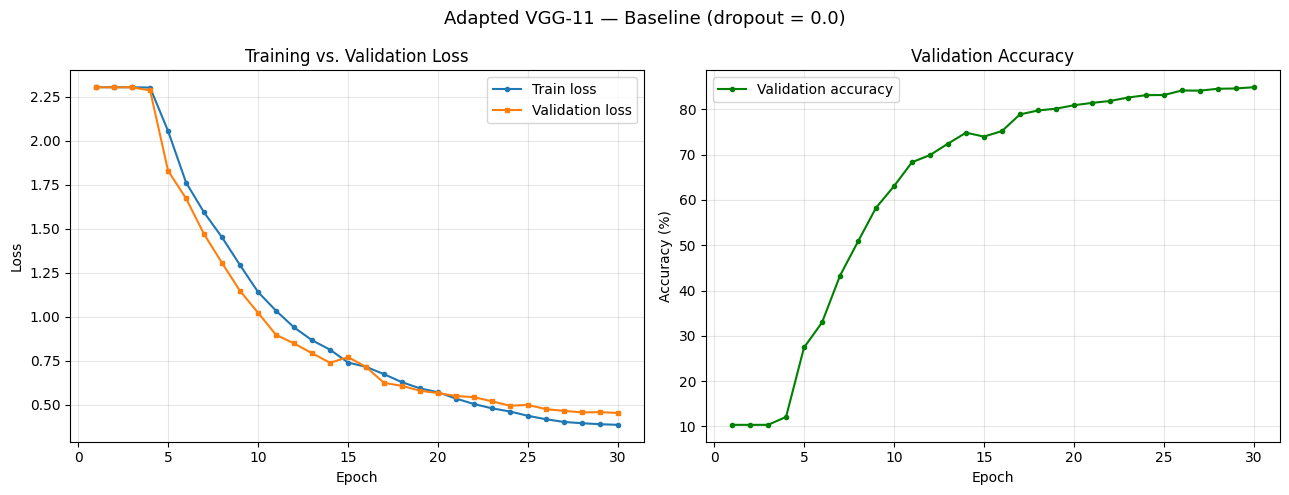

In [20]:
import matplotlib.pyplot as plt

h = vgg_history
epochs = range(1, len(h["train_loss"]) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(epochs, h["train_loss"], label="Train loss", marker='o', markersize=3)
ax1.plot(epochs, h["val_loss"], label="Validation loss", marker='s', markersize=3)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.set_title("Training vs. Validation Loss")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, h["val_acc"], label="Validation accuracy", color="green", marker='o', markersize=3)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)"); ax2.set_title("Validation Accuracy")
ax2.legend(); ax2.grid(True, alpha=0.3)

fig.suptitle("Adapted VGG-11 — Baseline (dropout = 0.0)", fontsize=13)
plt.tight_layout(); plt.show()

Evaluation - test acc and confustion matrix

VGG final test accuracy: 83.56%


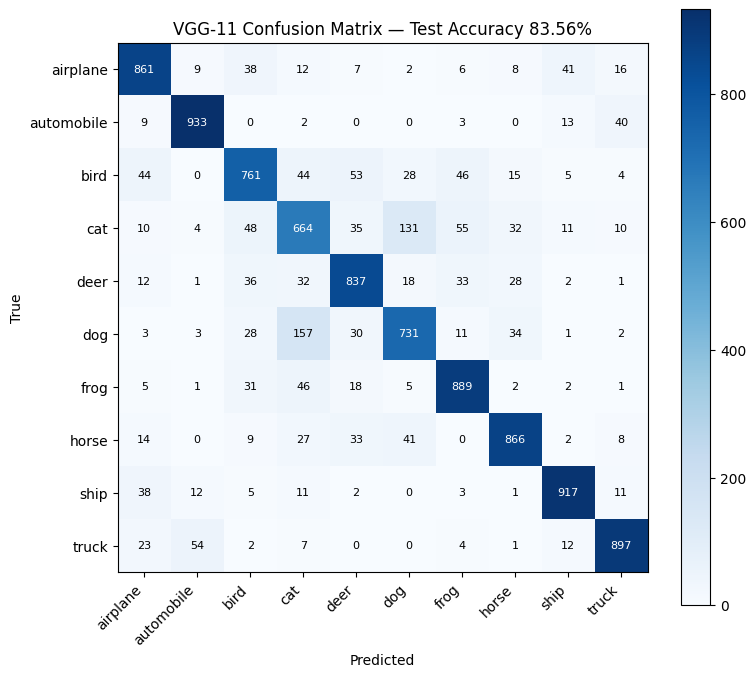

In [21]:
import numpy as np
import matplotlib.pyplot as plt

vgg_model.load_state_dict(vgg_best_state)
vgg_model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        all_preds.append(vgg_model(images).argmax(1).cpu())
        all_labels.append(labels)
all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

# test accuracy
vgg_test_acc = 100.0 * (all_preds == all_labels).mean()
print(f"VGG final test accuracy: {vgg_test_acc:.2f}%")

# Confusion matrix
classes = full_train.classes
n = len(classes)
cm = np.zeros((n, n), dtype=int)
np.add.at(cm, (all_labels, all_preds), 1)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Blues'); fig.colorbar(im)
ax.set(xticks=range(n), yticks=range(n), xticklabels=classes, yticklabels=classes,
       xlabel='Predicted', ylabel='True',
       title=f'VGG-11 Confusion Matrix — Test Accuracy {vgg_test_acc:.2f}%')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
for i in range(n):
    for j in range(n):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=8)
plt.tight_layout(); plt.show()

Part B : Dropout and Cross-Model Comparison

In [22]:
import copy, time
import torch
import torch.nn as nn

EPOCHS = 30
LR = 0.05
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4

vgg_results = {}

for p in [0.3, 0.5]:
    print(f"\n{'='*55}\nVGG — dropout_p = {p}\n{'='*55}")

    torch.manual_seed(SEED)
    model = AdaptedVGG(vgg11_cfg, num_classes=10, head_hidden=256, dropout_p=p).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    history = {"train_loss": [], "val_loss": [], "val_acc": [], "epoch_time": []}
    best_acc, best_state = 0.0, None

    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()
        model.train()
        running, n = 0.0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            running += loss.item() * images.size(0); n += images.size(0)
        train_loss = running / n

        model.eval()
        vrunning, correct, vn = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                out = model(images)
                vrunning += criterion(out, labels).item() * images.size(0)
                correct += (out.argmax(1) == labels).sum().item(); vn += images.size(0)
        val_loss, val_acc = vrunning / vn, 100.0 * correct / vn
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["epoch_time"].append(time.time() - t0)
        if val_acc > best_acc:
            best_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        print(f"epoch {epoch:2d}/{EPOCHS} | train {train_loss:.3f} | val {val_loss:.3f} | val_acc {val_acc:5.2f}%")

    vgg_results[p] = {"history": history, "best_val_acc": best_acc, "best_state": best_state}
    print(f"VGG dropout {p}: best val acc {best_acc:.2f}%")

print("\nDone. VGG baseline was 84.56%. Dropout results:")
for p in vgg_results:
    print(f"  dropout {p}: {vgg_results[p]['best_val_acc']:.2f}%")


VGG — dropout_p = 0.3
epoch  1/30 | train 2.303 | val 2.303 | val_acc 10.36%
epoch  2/30 | train 2.303 | val 2.303 | val_acc 10.36%
epoch  3/30 | train 2.303 | val 2.301 | val_acc 10.36%
epoch  4/30 | train 2.204 | val 1.994 | val_acc 24.78%
epoch  5/30 | train 1.851 | val 1.765 | val_acc 28.98%
epoch  6/30 | train 1.653 | val 1.531 | val_acc 40.56%
epoch  7/30 | train 1.511 | val 1.369 | val_acc 47.78%
epoch  8/30 | train 1.352 | val 1.254 | val_acc 54.36%
epoch  9/30 | train 1.209 | val 1.092 | val_acc 60.60%
epoch 10/30 | train 1.079 | val 0.947 | val_acc 66.68%
epoch 11/30 | train 0.977 | val 0.857 | val_acc 69.62%
epoch 12/30 | train 0.902 | val 0.761 | val_acc 73.46%
epoch 13/30 | train 0.833 | val 0.811 | val_acc 71.78%
epoch 14/30 | train 0.770 | val 0.739 | val_acc 74.96%
epoch 15/30 | train 0.735 | val 0.737 | val_acc 74.52%
epoch 16/30 | train 0.689 | val 0.619 | val_acc 78.74%
epoch 17/30 | train 0.645 | val 0.608 | val_acc 79.08%
epoch 18/30 | train 0.610 | val 0.571 | va

Problem 3: ResNet-11 vs ResNet-18 on CIFAR-10

Part A: ResNet-18 Implementation

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != self.expansion * out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, self.expansion * out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out


class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10, dropout_p=0.0):
        super().__init__()
        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

        self.layer1 = self._make_layer(block, 64,  num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        self.dropout = nn.Dropout(dropout_p)
        self.linear = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_channels, out_channels, s))
            self.in_channels = out_channels * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = F.adaptive_avg_pool2d(out, 1)
        out = out.view(out.size(0), -1)
        out = self.dropout(out)
        out = self.linear(out)
        return out

def ResNet11(num_classes=10, dropout_p=0.0):
    return ResNet(BasicBlock, [1, 1, 1, 1], num_classes, dropout_p)

def ResNet18(num_classes=10, dropout_p=0.0):
    return ResNet(BasicBlock, [2, 2, 2, 2], num_classes, dropout_p)

Sanity Check

In [24]:
from torchsummary import summary
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

resnet11 = ResNet11(num_classes=10).to(device)
resnet18 = ResNet18(num_classes=10).to(device)

def count(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print(f"ResNet-11 parameters: {count(resnet11):,}")
print(f"ResNet-18 parameters: {count(resnet18):,}")
print()

print("="*60)
print("ResNet-18 summary:")
print("="*60)
summary(resnet18, (3, 32, 32))

ResNet-11 parameters: 4,903,242
ResNet-18 parameters: 11,173,962

ResNet-18 summary:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,728
       BatchNorm2d-2           [-1, 64, 32, 32]             128
            Conv2d-3           [-1, 64, 32, 32]          36,864
       BatchNorm2d-4           [-1, 64, 32, 32]             128
            Conv2d-5           [-1, 64, 32, 32]          36,864
       BatchNorm2d-6           [-1, 64, 32, 32]             128
        BasicBlock-7           [-1, 64, 32, 32]               0
            Conv2d-8           [-1, 64, 32, 32]          36,864
       BatchNorm2d-9           [-1, 64, 32, 32]             128
           Conv2d-10           [-1, 64, 32, 32]          36,864
      BatchNorm2d-11           [-1, 64, 32, 32]             128
       BasicBlock-12           [-1, 64, 32, 32]               0
           Conv2d-

Epoch Training ResNet-11 and ResNet-18

In [25]:
import copy, time
import torch
import torch.nn as nn

EPOCHS = 50
LR = 0.05
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4
SEED = 42

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

models_to_train = {
    "ResNet-18": ResNet18,
    "ResNet-11": ResNet11,
}

resnet_results = {}

for name, builder in models_to_train.items():
    print(f"\n{'='*55}\nTraining {name}\n{'='*55}")

    torch.manual_seed(SEED)
    model = builder(num_classes=10, dropout_p=0.0).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    history = {"train_loss": [], "val_loss": [], "val_acc": [], "epoch_time": []}
    best_acc, best_state = 0.0, None

    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()
        model.train()
        running, n = 0.0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            running += loss.item() * images.size(0); n += images.size(0)
        train_loss = running / n

        model.eval()
        vrunning, correct, vn = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                out = model(images)
                vrunning += criterion(out, labels).item() * images.size(0)
                correct += (out.argmax(1) == labels).sum().item(); vn += images.size(0)
        val_loss, val_acc = vrunning / vn, 100.0 * correct / vn
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["epoch_time"].append(time.time() - t0)
        if val_acc > best_acc:
            best_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        print(f"epoch {epoch:2d}/{EPOCHS} | train {train_loss:.3f} | val {val_loss:.3f} | val_acc {val_acc:5.2f}%")

    avg_epoch = sum(history["epoch_time"]) / len(history["epoch_time"])
    resnet_results[name] = {"history": history, "best_val_acc": best_acc,
                            "best_state": best_state, "avg_epoch_time": avg_epoch}
    print(f"{name}: best val acc {best_acc:.2f}% | avg epoch time {avg_epoch:.1f}s")

print("\nDone.")
for name in resnet_results:
    r = resnet_results[name]
    print(f"  {name}: {r['best_val_acc']:.2f}%  ({r['avg_epoch_time']:.1f}s/epoch)")


Training ResNet-18
epoch  1/50 | train 1.632 | val 1.513 | val_acc 47.52%
epoch  2/50 | train 1.140 | val 1.011 | val_acc 64.62%
epoch  3/50 | train 0.886 | val 0.819 | val_acc 70.28%
epoch  4/50 | train 0.737 | val 0.698 | val_acc 76.16%
epoch  5/50 | train 0.636 | val 0.659 | val_acc 77.10%
epoch  6/50 | train 0.557 | val 0.634 | val_acc 78.20%
epoch  7/50 | train 0.510 | val 0.694 | val_acc 77.06%
epoch  8/50 | train 0.460 | val 0.511 | val_acc 82.16%
epoch  9/50 | train 0.423 | val 0.519 | val_acc 81.76%
epoch 10/50 | train 0.391 | val 0.459 | val_acc 84.28%
epoch 11/50 | train 0.363 | val 0.424 | val_acc 85.38%
epoch 12/50 | train 0.338 | val 0.456 | val_acc 85.26%
epoch 13/50 | train 0.314 | val 0.418 | val_acc 85.96%
epoch 14/50 | train 0.289 | val 0.339 | val_acc 88.76%
epoch 15/50 | train 0.266 | val 0.507 | val_acc 83.70%
epoch 16/50 | train 0.250 | val 0.438 | val_acc 85.90%
epoch 17/50 | train 0.236 | val 0.430 | val_acc 85.96%
epoch 18/50 | train 0.219 | val 0.453 | val_a

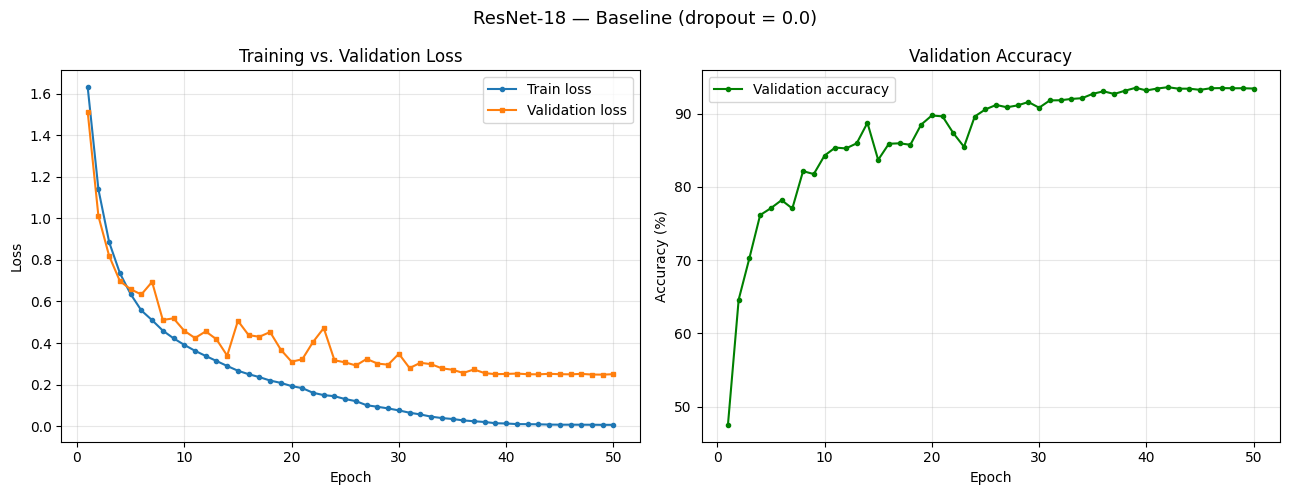

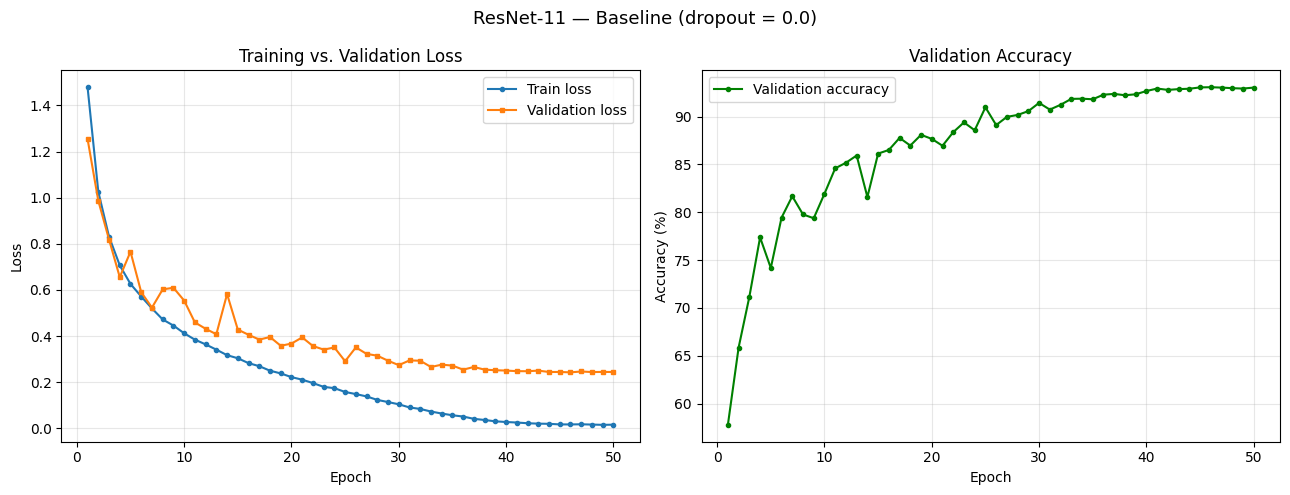

In [26]:
import matplotlib.pyplot as plt

for name in ["ResNet-18", "ResNet-11"]:
    h = resnet_results[name]["history"]
    epochs = range(1, len(h["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    ax1.plot(epochs, h["train_loss"], label="Train loss", marker='o', markersize=3)
    ax1.plot(epochs, h["val_loss"], label="Validation loss", marker='s', markersize=3)
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.set_title("Training vs. Validation Loss")
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, h["val_acc"], label="Validation accuracy", color="green", marker='o', markersize=3)
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)"); ax2.set_title("Validation Accuracy")
    ax2.legend(); ax2.grid(True, alpha=0.3)

    fig.suptitle(f"{name} — Baseline (dropout = 0.0)", fontsize=13)
    plt.tight_layout(); plt.show()

Evaluation

ResNet-18 final test accuracy: 93.07%


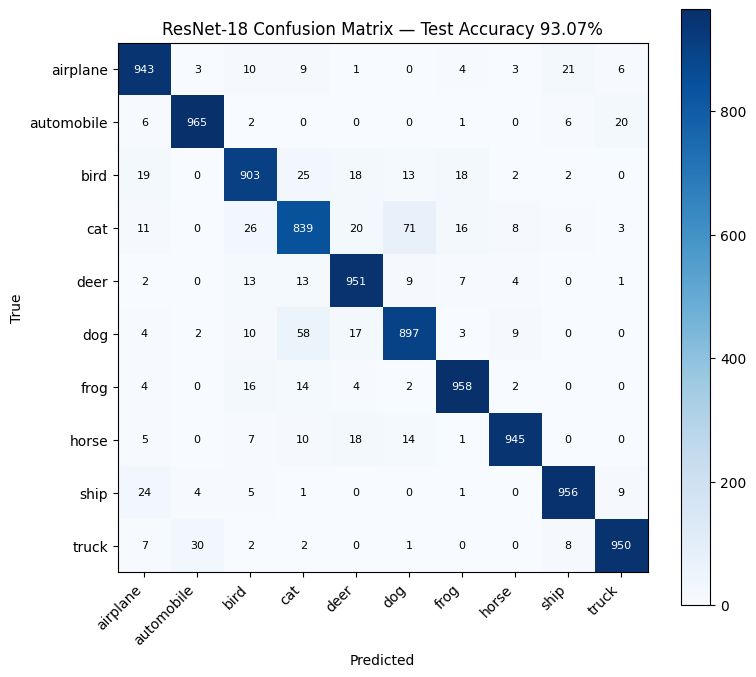

ResNet-11 final test accuracy: 92.72%


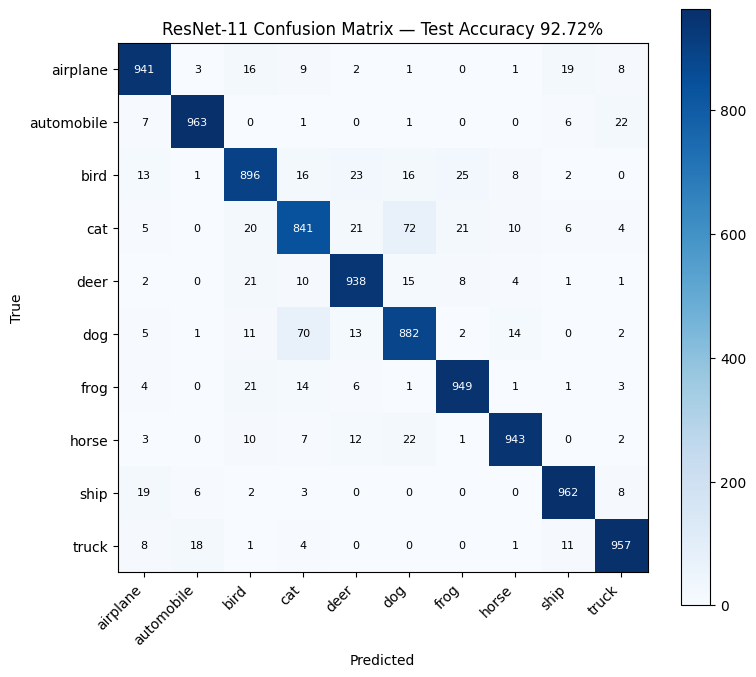

In [27]:
import numpy as np
import matplotlib.pyplot as plt

classes = full_train.classes

eval_models = {
    "ResNet-18": (ResNet18, resnet_results["ResNet-18"]["best_state"]),
    "ResNet-11": (ResNet11, resnet_results["ResNet-11"]["best_state"]),
}

for name, (builder, best_state) in eval_models.items():
    model = builder(num_classes=10).to(device)
    model.load_state_dict(best_state)
    model.eval()

    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            all_preds.append(model(images).argmax(1).cpu())
            all_labels.append(labels)
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    test_acc = 100.0 * (all_preds == all_labels).mean()
    print(f"{name} final test accuracy: {test_acc:.2f}%")

    resnet_results[name]["test_acc"] = test_acc

    n = len(classes)
    cm = np.zeros((n, n), dtype=int)
    np.add.at(cm, (all_labels, all_preds), 1)

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm, cmap='Blues'); fig.colorbar(im)
    ax.set(xticks=range(n), yticks=range(n), xticklabels=classes, yticklabels=classes,
           xlabel='Predicted', ylabel='True',
           title=f'{name} Confusion Matrix — Test Accuracy {test_acc:.2f}%')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    for i in range(n):
        for j in range(n):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=8)
    plt.tight_layout(); plt.show()

Part B: Dropout and Final Comparison

In [28]:
import copy, time
import torch
import torch.nn as nn

EPOCHS = 50
LR = 0.05
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4

resnet_dropout_results = {}

builders = {"ResNet-18": ResNet18, "ResNet-11": ResNet11}

for name, builder in builders.items():
    for p in [0.3, 0.5]:
        print(f"\n{'='*55}\n{name} — dropout_p = {p}\n{'='*55}")

        torch.manual_seed(SEED)
        model = builder(num_classes=10, dropout_p=p).to(device)

        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

        history = {"train_loss": [], "val_loss": [], "val_acc": [], "epoch_time": []}
        best_acc, best_state = 0.0, None

        for epoch in range(1, EPOCHS + 1):
            t0 = time.time()
            model.train()
            running, n = 0.0, 0
            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)
                optimizer.zero_grad()
                loss = criterion(model(images), labels)
                loss.backward()
                optimizer.step()
                running += loss.item() * images.size(0); n += images.size(0)
            train_loss = running / n

            model.eval()
            vrunning, correct, vn = 0.0, 0, 0
            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(device), labels.to(device)
                    out = model(images)
                    vrunning += criterion(out, labels).item() * images.size(0)
                    correct += (out.argmax(1) == labels).sum().item(); vn += images.size(0)
            val_loss, val_acc = vrunning / vn, 100.0 * correct / vn
            scheduler.step()

            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["val_acc"].append(val_acc)
            history["epoch_time"].append(time.time() - t0)
            if val_acc > best_acc:
                best_acc = val_acc
                best_state = copy.deepcopy(model.state_dict())

            if epoch % 5 == 0 or epoch == 1:
                print(f"epoch {epoch:2d}/{EPOCHS} | train {train_loss:.3f} | val {val_loss:.3f} | val_acc {val_acc:5.2f}%")

        resnet_dropout_results[(name, p)] = {"history": history, "best_val_acc": best_acc, "best_state": best_state}
        print(f"{name} dropout {p}: best val acc {best_acc:.2f}%")

print("\n" + "="*55)
print("Summary (baselines: ResNet-18 93.86%, ResNet-11 93.46%)")
for (name, p), r in resnet_dropout_results.items():
    print(f"  {name} dropout {p}: {r['best_val_acc']:.2f}%")


ResNet-18 — dropout_p = 0.3
epoch  1/50 | train 1.665 | val 1.325 | val_acc 52.48%
epoch  5/50 | train 0.652 | val 0.652 | val_acc 77.34%
epoch 10/50 | train 0.396 | val 0.424 | val_acc 85.96%
epoch 15/50 | train 0.267 | val 0.446 | val_acc 85.42%
epoch 20/50 | train 0.196 | val 0.331 | val_acc 88.94%
epoch 25/50 | train 0.139 | val 0.340 | val_acc 89.90%
epoch 30/50 | train 0.082 | val 0.270 | val_acc 92.04%
epoch 35/50 | train 0.040 | val 0.269 | val_acc 92.54%
epoch 40/50 | train 0.015 | val 0.253 | val_acc 93.48%
epoch 45/50 | train 0.008 | val 0.246 | val_acc 93.56%
epoch 50/50 | train 0.007 | val 0.246 | val_acc 93.54%
ResNet-18 dropout 0.3: best val acc 93.62%

ResNet-18 — dropout_p = 0.5
epoch  1/50 | train 1.783 | val 1.348 | val_acc 50.20%
epoch  5/50 | train 0.700 | val 0.904 | val_acc 69.82%
epoch 10/50 | train 0.429 | val 0.419 | val_acc 85.42%
epoch 15/50 | train 0.296 | val 0.648 | val_acc 80.04%
epoch 20/50 | train 0.218 | val 0.332 | val_acc 89.32%
epoch 25/50 | train

In [29]:
import numpy as np

best_rn18 = ResNet18(num_classes=10, dropout_p=0.3).to(device)
best_rn18.load_state_dict(resnet_dropout_results[("ResNet-18", 0.3)]["best_state"])
best_rn18.eval()

correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        preds = best_rn18(images).argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

rn18_best_test = 100.0 * correct / total
print(f"ResNet-18 (dropout 0.3) test accuracy: {rn18_best_test:.2f}%")

ResNet-18 (dropout 0.3) test accuracy: 92.98%


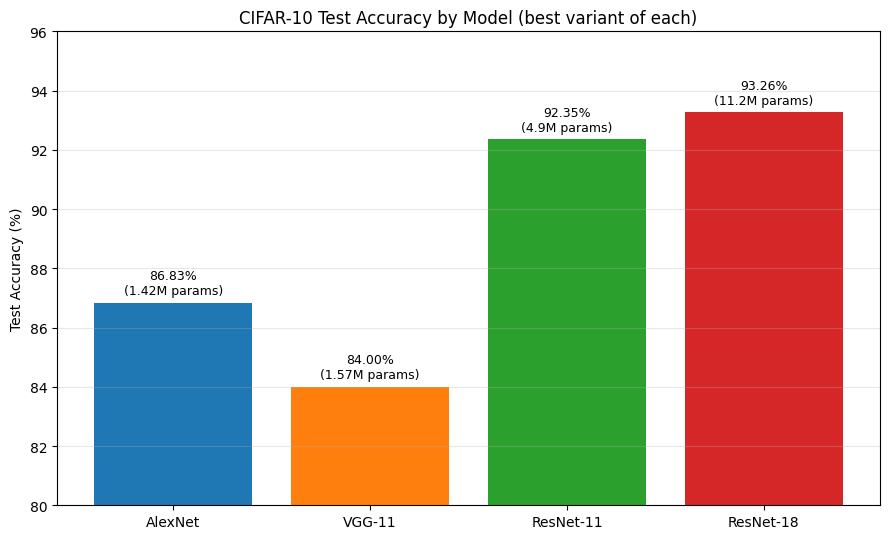

In [30]:
import matplotlib.pyplot as plt

models = ["AlexNet", "VGG-11", "ResNet-11", "ResNet-18"]
test_accs = [86.83, 84.00, 92.35, 93.26]
params_m  = [1.42, 1.57, 4.9, 11.2]   # millions

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(models, test_accs, color=["tab:blue", "tab:orange", "tab:green", "tab:red"])

ax.set_ylabel("Test Accuracy (%)")
ax.set_title("CIFAR-10 Test Accuracy by Model (best variant of each)")
ax.set_ylim(80, 96)
ax.grid(True, axis='y', alpha=0.3)

# accuracy and parameter count
for bar, acc, p in zip(bars, test_accs, params_m):
    ax.text(bar.get_x() + bar.get_width()/2, acc + 0.2,
            f"{acc:.2f}%\n({p}M params)", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()